In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        "N": 16384 * 16384,
        "nx": 16384,
        "ny": 16384,
        "dx": 8.5e-8,          # 85 nm
        "z_detector": 4.0,     # 探测器位置 4.0 m
        "detector_size": 0.85e-3,       # 探测器 0.85 mm
        "detector_size_y": 0.85e-3,
        "detector_pixel_size_x": 2e-7, # 像素可调
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [9999, 10001],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 10,
        "seed": 1,
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 1.0,            # 样品位于 1.0 m
            "pixel_size_x": 5e-7,      # 样品内部高分辨率
            "pixel_size_y": 5e-7,
            "pixel_size_z": 5e-7,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/50um_10um_hollow_non_spherical.npy",
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-06-11 13:19:36,065 INFO: Setting up simulation
2026-06-11 13:19:36,067 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m
2026-06-11 13:19:36,571 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-06-11 13:19:38,157 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260611_131936598994


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                            | 0/10 [00:00<?, ?it/s]

[2026-06-11 13:19:38.950] [info] Detector 2D mode
[2026-06-11 13:19:38.950] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260611_131936598994/00000000
[2026-06-11 13:19:38.950] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-11 13:19:38.950] [info] GPU memory required for wavefield: 2048 MB
[2026-06-11 13:19:39.272] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-11 13:19:53.914] [info]   Number of optical elements: 1
[2026-06-11 13:23:27.577] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-11 13:23:27.577] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-11 13:23:27.577] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08


 10%|████████▎                                                                          | 1/10 [03:50<34:31, 230.17s/it]

[2026-06-11 13:23:28.258] [info] 2D Simulation finished in 244.15762626 seconds
[2026-06-11 13:23:29.088] [info] Detector 2D mode
[2026-06-11 13:23:29.089] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260611_131936598994/00000001
[2026-06-11 13:23:29.089] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-11 13:23:29.089] [info] GPU memory required for wavefield: 2048 MB
[2026-06-11 13:23:29.399] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-11 13:23:46.213] [info]   Number of optical elements: 1
[2026-06-11 13:27:17.770] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-11 13:27:17.770] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-11 13:27:17.770] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08


 20%|████████████████▌                                                                  | 2/10 [07:40<30:41, 230.17s/it]

...

[2026-06-11 13:50:14.849] [info] 2D Simulation finished in 237.572934602 seconds
[2026-06-11 13:50:15.714] [info] Detector 2D mode
[2026-06-11 13:50:15.714] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260611_131936598994/00000008
[2026-06-11 13:50:15.714] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-11 13:50:15.714] [info] GPU memory required for wavefield: 2048 MB
[2026-06-11 13:50:16.066] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-11 13:50:31.349] [info]   Number of optical elements: 1
[2026-06-11 13:54:16.429] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-11 13:54:16.429] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-11 13:54:16.429] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [34:39<03:53, 233.53s/it]

[2026-06-11 13:54:17.105] [info] 2D Simulation finished in 256.878134549 seconds
[2026-06-11 13:54:18.151] [info] Detector 2D mode
[2026-06-11 13:54:18.151] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260611_131936598994/00000009
[2026-06-11 13:54:18.151] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-11 13:54:18.151] [info] GPU memory required for wavefield: 2048 MB
[2026-06-11 13:54:18.604] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-11 13:54:58.537] [info]   Number of optical elements: 1
[2026-06-11 13:58:46.053] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-11 13:58:46.053] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-11 13:58:46.053] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [39:08<00:00, 234.87s/it]

[2026-06-11 13:58:46.750] [info] 2D Simulation finished in 286.139050751 seconds


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 10
nr phase steps: 1
nr detector pixels: 4250 4250


[[1.2224274e-14 8.3347635e-15 8.5273568e-15 ... 1.2604031e-14
  8.3092856e-15 8.1469975e-15]
 [8.3036868e-15 5.6371118e-15 5.7546063e-15 ... 8.7044646e-15
  5.7090461e-15 5.5869988e-15]
 [8.3896394e-15 5.6764320e-15 5.8324567e-15 ... 8.7344750e-15
  5.7678662e-15 5.6937309e-15]
 ...
 [1.2991037e-14 8.7689543e-15 9.0259136e-15 ... 1.3661829e-14
  8.9654787e-15 8.7720384e-15]
 [8.4701203e-15 5.7310952e-15 5.9028820e-15 ... 8.7622602e-15
  5.7727985e-15 5.7086277e-15]
 [8.3395577e-15 5.6483875e-15 5.7823958e-15 ... 8.7454297e-15
  5.7604127e-15 5.6577371e-15]]


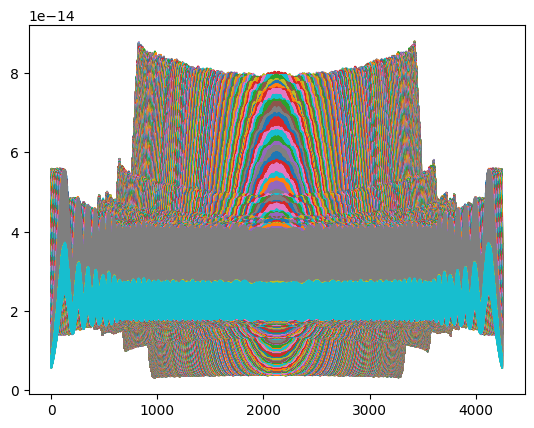

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

In [10]:
from contextlib import redirect_stdout
with open('output_3d_test_DT_nonsphere_260611.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            for j in range(len(wf[0][i])):
                print(wf[0][i][j])
            print('\n')

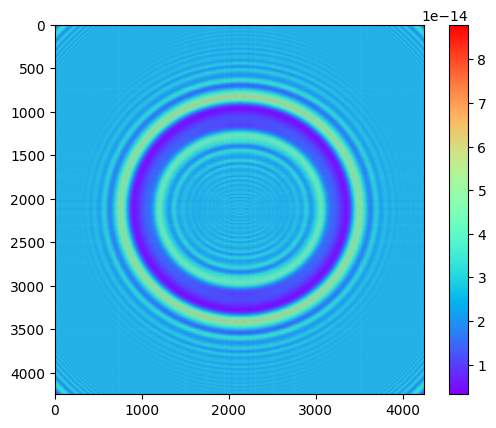

In [11]:
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

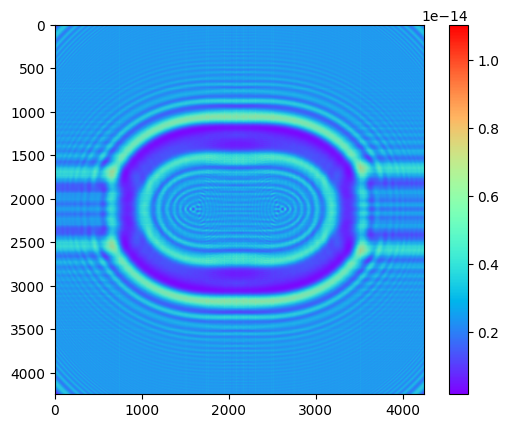

In [11]:
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

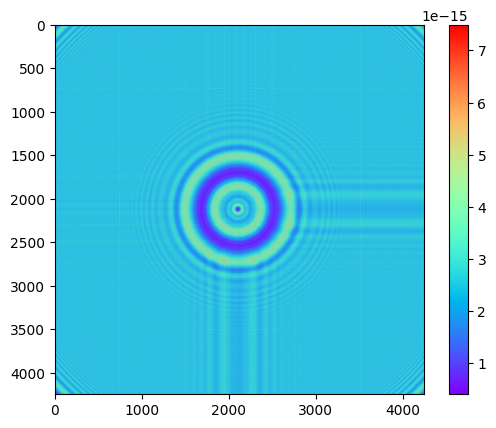

In [12]:
# one single shot
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()